<a href="https://colab.research.google.com/github/KerimjanKSTU/About_me/blob/main/Practical_2_EDA_Level_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Work №2 — Exploratory Data Analysis
## Variant B
Dataset: procrastination_survey_dataset.csv

Цель работы: провести полный разведочный анализ данных, исследовать типы признаков,
распределения, выбросы, категориальные признаки, корреляции и целевую переменную.


In [1]:
!ls -lh *.csv

-rw-r--r-- 1 root root 95K Sep 23 03:28 procrastination_survey_dataset.csv


In [3]:
import csv
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [4]:
!pip install seaborn

In [5]:
FILE = "procrastination_survey_dataset.csv"

with open(FILE, encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)

    header = next(reader)

    raw_rows = [
        row for row in reader
        if row
    ]

row_lengths = Counter(len(row) for row in raw_rows)

print("Количество колонок в заголовке:", len(header))
print("Количество строк данных:", len(raw_rows))
print("Число полей в строках:", row_lengths)


Количество колонок в заголовке: 68
Количество строк данных: 300
Число полей в строках: Counter({69: 235, 68: 65})


In [6]:
FILE = "procrastination_survey_dataset.csv"

with open(FILE, encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)

    header = next(reader)

    raw_rows = [
        row for row in reader
        if row
    ]

row_lengths = Counter(len(row) for row in raw_rows)

print("Количество колонок в заголовке:", len(header))
print("Количество строк данных:", len(raw_rows))
print("Число полей в строках:", row_lengths)

Количество колонок в заголовке: 68
Количество строк данных: 300
Число полей в строках: Counter({69: 235, 68: 65})


In [7]:
columns = (
    header[:47]
    + ["unlabeled_extra_field"]
    + header[47:]
)

fixed_rows = []

for row in raw_rows:

    if len(row) == 69:
        # Строка уже содержит дополнительное значение
        fixed_rows.append(row)

    elif len(row) == 68:
        # В этой строке дополнительного значения нет
        row = row[:47] + [None] + row[47:]
        fixed_rows.append(row)

    else:
        raise ValueError(
            f"Обнаружена строка с неожиданным количеством полей: {len(row)}"
        )

df = pd.DataFrame(fixed_rows, columns=columns)

# Автоматически переводим числовые столбцы из текста в числа
for col in df.columns:

    converted = pd.to_numeric(df[col], errors="coerce")

    if converted.notna().mean() >= 0.70:
        df[col] = converted

print("Размер DataFrame:", df.shape)
display(df.head())

Размер DataFrame: (300, 69)


,participant_id,data_source,synthetic_flag,age,age_group,gender,education_level,employment_status,occupation_category,average_sleep_hours,sleep_quality,daily_screen_time_hours,daily_social_media_hours,physical_activity_frequency,work_hours_per_day,study_hours_per_day,commute_hours_per_day,perceived_workload,task_type,task_importance,task_difficulty,task_interest,task_anxiety,task_clarity,task_complexity,task_duration_estimate_hours,deadline_days_remaining,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,unlabeled_extra_field,planning_style,scheduling_method,primary_social_platform,social_media_check_frequency,social_media_during_work_or_study,social_media_as_task_avoidance,notifications_enabled,primary_procrastination_trigger,stress_rating,mood_rating,energy_rating,concentration_difficulty,feeling_overwhelmed_frequency,work_life_balance,perceived_control,procrastination_score,scheduling_score,task_anxiety_score,workload_score,social_media_avoidance_score,wellbeing_score
0,P0001,synthetic_ai,1,19,18-20,Male,Undergraduate,Student,Education,6.5,Fair,7.0,3.5,1-2x/week,0.0,5.0,0.5,Moderate,Exam preparation,5,4,2,4,3,4,6.0,7,4,4,3,4,3,4,4,5,3,4,2,3,2,2,3,2,2,3,4,2,NaN,Deadline-driven,Mental planning,Instagram,Every few hours,Often,4,Yes,Low motivation,7,5,4,6,6,5,4,3.8,2.6,4.00,2.19,4.00,4.2
1,P0002,synthetic_ai,1,34,30-39,Female,Postgraduate,Full-time employed,Healthcare,7.0,Good,6.5,1.5,3-4x/week,9.0,0.5,1.0,Heavy,Work project,5,4,3,3,4,4,8.0,5,3,3,2,3,2,3,3,3,2,3,4,4,3,4,4,4,3,4,3,2,4.0,Weekly planner,Phone calendar,LinkedIn,Once a day,Rarely,2,Yes,Fatigue,7,6,5,4,6,5,5,2.8,3.6,3.67,3.28,2.33,5.5
2,P0003,synthetic_ai,1,22,21-24,Female,Undergraduate,Student,Education,6.0,Poor,9.0,5.0,Never,0.0,6.0,0.0,Moderate,Academic assignment,4,3,2,4,2,3,4.0,3,5,5,4,5,4,4,3,5,3,4,2,2,2,2,2,2,2,4,4,1,NaN,Reactive planning,Mental planning,TikTok,Constantly,Often,5,Yes,Social media,8,4,3,7,7,4,3,4.2,2.1,3.33,1.88,4.67,3.6
3,P0004,synthetic_ai,1,45,40-49,Male,Undergraduate,Full-time employed,Technology,7.5,Good,8.0,2.0,3-4x/week,9.0,0.0,1.5,Heavy,Work project,5,5,3,4,3,5,10.0,10,3,4,3,3,3,3,4,4,3,4,4,3,4,4,4,4,3,4,3,2,4.0,Weekly planner,Computer calendar,LinkedIn,2-3 times a day,Sometimes,3,Yes,Task difficulty,6,6,6,5,5,6,6,3.4,3.6,4.33,3.28,3.00,5.8
4,P0005,synthetic_ai,1,28,25-29,Non-binary,Postgraduate,Full-time employed,Research,6.5,Fair,7.5,2.5,1-2x/week,8.0,1.5,0.5,Heavy,Work project,4,4,3,3,3,4,7.0,14,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3.0,Mixed strategy,Todo application,Reddit,2-3 times a day,Sometimes,3,No,Lack of clarity,6,6,6,5,5,6,5,3.0,3.0,3.67,2.94,3.00,5.4


In [10]:
print("Размер:", df.shape)

print("\nПервые строки:")
display(df.head())

print("\nПоследние строки:")
display(df.tail())

print("\nОбщая информация:")
df.info()

Размер: (300, 69)

Первые строки:


,participant_id,data_source,synthetic_flag,age,age_group,gender,education_level,employment_status,occupation_category,average_sleep_hours,sleep_quality,daily_screen_time_hours,daily_social_media_hours,physical_activity_frequency,work_hours_per_day,study_hours_per_day,commute_hours_per_day,perceived_workload,task_type,task_importance,task_difficulty,task_interest,task_anxiety,task_clarity,task_complexity,task_duration_estimate_hours,deadline_days_remaining,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,unlabeled_extra_field,planning_style,scheduling_method,primary_social_platform,social_media_check_frequency,social_media_during_work_or_study,social_media_as_task_avoidance,notifications_enabled,primary_procrastination_trigger,stress_rating,mood_rating,energy_rating,concentration_difficulty,feeling_overwhelmed_frequency,work_life_balance,perceived_control,procrastination_score,scheduling_score,task_anxiety_score,workload_score,social_media_avoidance_score,wellbeing_score
0,P0001,synthetic_ai,1,19,18-20,Male,Undergraduate,Student,Education,6.5,Fair,7.0,3.5,1-2x/week,0.0,5.0,0.5,Moderate,Exam preparation,5,4,2,4,3,4,6.0,7,4,4,3,4,3,4,4,5,3,4,2,3,2,2,3,2,2,3,4,2,NaN,Deadline-driven,Mental planning,Instagram,Every few hours,Often,4,Yes,Low motivation,7,5,4,6,6,5,4,3.8,2.6,4.00,2.19,4.00,4.2
1,P0002,synthetic_ai,1,34,30-39,Female,Postgraduate,Full-time employed,Healthcare,7.0,Good,6.5,1.5,3-4x/week,9.0,0.5,1.0,Heavy,Work project,5,4,3,3,4,4,8.0,5,3,3,2,3,2,3,3,3,2,3,4,4,3,4,4,4,3,4,3,2,4.0,Weekly planner,Phone calendar,LinkedIn,Once a day,Rarely,2,Yes,Fatigue,7,6,5,4,6,5,5,2.8,3.6,3.67,3.28,2.33,5.5
2,P0003,synthetic_ai,1,22,21-24,Female,Undergraduate,Student,Education,6.0,Poor,9.0,5.0,Never,0.0,6.0,0.0,Moderate,Academic assignment,4,3,2,4,2,3,4.0,3,5,5,4,5,4,4,3,5,3,4,2,2,2,2,2,2,2,4,4,1,NaN,Reactive planning,Mental planning,TikTok,Constantly,Often,5,Yes,Social media,8,4,3,7,7,4,3,4.2,2.1,3.33,1.88,4.67,3.6
3,P0004,synthetic_ai,1,45,40-49,Male,Undergraduate,Full-time employed,Technology,7.5,Good,8.0,2.0,3-4x/week,9.0,0.0,1.5,Heavy,Work project,5,5,3,4,3,5,10.0,10,3,4,3,3,3,3,4,4,3,4,4,3,4,4,4,4,3,4,3,2,4.0,Weekly planner,Computer calendar,LinkedIn,2-3 times a day,Sometimes,3,Yes,Task difficulty,6,6,6,5,5,6,6,3.4,3.6,4.33,3.28,3.00,5.8
4,P0005,synthetic_ai,1,28,25-29,Non-binary,Postgraduate,Full-time employed,Research,6.5,Fair,7.5,2.5,1-2x/week,8.0,1.5,0.5,Heavy,Work project,4,4,3,3,3,4,7.0,14,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3.0,Mixed strategy,Todo application,Reddit,2-3 times a day,Sometimes,3,No,Lack of clarity,6,6,6,5,5,6,5,3.0,3.0,3.67,2.94,3.00,5.4



Последние строки:


,participant_id,data_source,synthetic_flag,age,age_group,gender,education_level,employment_status,occupation_category,average_sleep_hours,sleep_quality,daily_screen_time_hours,daily_social_media_hours,physical_activity_frequency,work_hours_per_day,study_hours_per_day,commute_hours_per_day,perceived_workload,task_type,task_importance,task_difficulty,task_interest,task_anxiety,task_clarity,task_complexity,task_duration_estimate_hours,deadline_days_remaining,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,unlabeled_extra_field,planning_style,scheduling_method,primary_social_platform,social_media_check_frequency,social_media_during_work_or_study,social_media_as_task_avoidance,notifications_enabled,primary_procrastination_trigger,stress_rating,mood_rating,energy_rating,concentration_difficulty,feeling_overwhelmed_frequency,work_life_balance,perceived_control,procrastination_score,scheduling_score,task_anxiety_score,workload_score,social_media_avoidance_score,wellbeing_score
295,P0296,synthetic_ai,1,54,50-59,Female,Postgraduate,Full-time employed,Healthcare,7.5,Good,5.5,1.0,Daily,8.0,0.0,1.0,Heavy,Health-related task,4,3,4,2,4,3,4.0,14,2,2,2,2,1,2,2,2,2,2,4,4,4,5,5,4,5,4,1,2,5.0,Calendar-based planning,Phone calendar,Facebook,Once a day,Never,1,No,Fear of failure,4,8,7,3,3,7,8,1.9,4.3,3.00,2.88,1.00,8.1
296,P0297,synthetic_ai,1,26,25-29,Male,Undergraduate,Full-time employed,Government,6.5,Fair,6.5,2.0,1-2x/week,8.0,0.0,1.0,Heavy,Email/administrative task,3,2,2,2,3,2,2.0,7,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3.0,Daily planner,Phone calendar,LinkedIn,2-3 times a day,Rarely,2,Yes,Boredom,5,7,6,4,4,6,6,3.0,3.0,2.00,2.88,2.00,6.2
297,P0298,synthetic_ai,1,31,30-39,Female,Undergraduate,Full-time employed,Retail,6.5,Fair,7.5,2.5,1-2x/week,7.5,0.0,1.0,Moderate,Email/administrative task,3,2,2,2,3,2,2.0,5,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3.0,Daily planner,Phone calendar,Instagram,2-3 times a day,Sometimes,3,Yes,Boredom,6,6,5,5,5,5,5,3.0,3.0,2.33,2.66,3.00,5.3
298,P0299,synthetic_ai,1,44,40-49,Male,Undergraduate,Full-time employed,Engineering,7.0,Good,7.5,2.0,3-4x/week,9.0,0.0,1.5,Heavy,Work project,5,5,3,4,4,5,9.0,5,3,3,3,3,3,3,3,3,2,3,4,4,4,4,4,4,4,4,3,2,4.0,Weekly planner,Computer calendar,YouTube,Once a day,Sometimes,2,Yes,Task difficulty,6,7,6,5,5,6,6,2.9,3.7,4.00,3.28,2.33,6.1
299,P0300,synthetic_ai,1,61,60+,Female,Undergraduate,Retired,Other,8.0,Good,3.5,0.5,Daily,0.0,0.0,0.0,Very light,Household task,2,2,4,1,5,2,2.0,30,1,1,2,1,2,2,1,1,2,1,5,4,4,5,5,4,5,5,1,2,5.0,Daily planner,Paper notebook,Facebook,Once a day,Never,1,No,Boredom,2,9,8,2,2,9,9,1.4,4.4,1.67,1.00,1.00,9.4



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 69 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   participant_id                     300 non-null    object 
 1   data_source                        300 non-null    object 
 2   synthetic_flag                     300 non-null    int64  
 3   age                                300 non-null    int64  
 4   age_group                          300 non-null    object 
 5   gender                             300 non-null    object 
 6   education_level                    300 non-null    object 
 7   employment_status                  300 non-null    object 
 8   occupation_category                300 non-null    object 
 9   average_sleep_hours                300 non-null    float64
 10  sleep_quality                      300 non-null    object 
 11  daily_screen_time_hours            300 

In [12]:
display(
    df.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,300,300,P0300,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_source,300,1,synthetic_ai,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
synthetic_flag,300.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
age,300.0,NaN,NaN,NaN,37.296667,13.918131,18.0,26.0,34.5,47.0,72.0
age_group,300,7,30-39,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,300,3,Female,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,300,6,Undergraduate,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,300,8,Full-time employed,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_category,300,13,Education,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_sleep_hours,300.0,NaN,NaN,NaN,6.828333,0.699759,5.5,6.5,7.0,7.0,8.5


In [13]:
quantitative_cols = [
    "age",
    "average_sleep_hours",
    "daily_screen_time_hours",
    "daily_social_media_hours",
    "work_hours_per_day",
    "study_hours_per_day",
    "commute_hours_per_day",
    "task_duration_estimate_hours",
    "deadline_days_remaining",
    "procrastination_score",
    "scheduling_score",
    "task_anxiety_score",
    "workload_score",
    "social_media_avoidance_score",
    "wellbeing_score"
]

display(
    df[quantitative_cols]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
age,300.0,37.30,13.92,18.0,26.00,34.50,47.00,72.00
average_sleep_hours,300.0,6.83,0.70,5.5,6.50,7.00,7.00,8.50
daily_screen_time_hours,300.0,7.10,1.95,2.5,6.00,7.50,8.50,11.00
daily_social_media_hours,300.0,2.47,1.57,0.5,1.50,2.00,3.50,6.00
work_hours_per_day,300.0,5.86,3.66,0.0,1.00,8.00,8.50,10.00
study_hours_per_day,300.0,1.23,1.93,0.0,0.00,0.00,2.00,6.00
commute_hours_per_day,300.0,0.70,0.55,0.0,0.00,1.00,1.00,1.50
task_duration_estimate_hours,300.0,5.74,2.70,2.0,4.00,5.00,7.25,12.00
deadline_days_remaining,300.0,10.04,7.95,1.0,5.00,7.00,14.00,30.00
procrastination_score,300.0,2.89,0.89,1.2,2.00,3.00,3.52,4.90


In [14]:
quantitative_cols = [
    "age",
    "average_sleep_hours",
    "daily_screen_time_hours",
    "daily_social_media_hours",
    "work_hours_per_day",
    "study_hours_per_day",
    "commute_hours_per_day",
    "task_duration_estimate_hours",
    "deadline_days_remaining",
    "procrastination_score",
    "scheduling_score",
    "task_anxiety_score",
    "workload_score",
    "social_media_avoidance_score",
    "wellbeing_score"
]

display(
    df[quantitative_cols]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
age,300.0,37.30,13.92,18.0,26.00,34.50,47.00,72.00
average_sleep_hours,300.0,6.83,0.70,5.5,6.50,7.00,7.00,8.50
daily_screen_time_hours,300.0,7.10,1.95,2.5,6.00,7.50,8.50,11.00
daily_social_media_hours,300.0,2.47,1.57,0.5,1.50,2.00,3.50,6.00
work_hours_per_day,300.0,5.86,3.66,0.0,1.00,8.00,8.50,10.00
study_hours_per_day,300.0,1.23,1.93,0.0,0.00,0.00,2.00,6.00
commute_hours_per_day,300.0,0.70,0.55,0.0,0.00,1.00,1.00,1.50
task_duration_estimate_hours,300.0,5.74,2.70,2.0,4.00,5.00,7.25,12.00
deadline_days_remaining,300.0,10.04,7.95,1.0,5.00,7.00,14.00,30.00
procrastination_score,300.0,2.89,0.89,1.2,2.00,3.00,3.52,4.90


In [15]:
duplicates = df.duplicated().sum()

print("Количество полных дубликатов:", duplicates)

Количество полных дубликатов: 0


In [16]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=True) <= 1
]

print("Константные признаки:")
print(constant_cols)

for col in constant_cols:
    print(
        "\n",
        col,
        df[col].value_counts(dropna=False).to_dict()
    )

Константные признаки:
['data_source', 'synthetic_flag']

 data_source {'synthetic_ai': 300}

 synthetic_flag {1: 300}


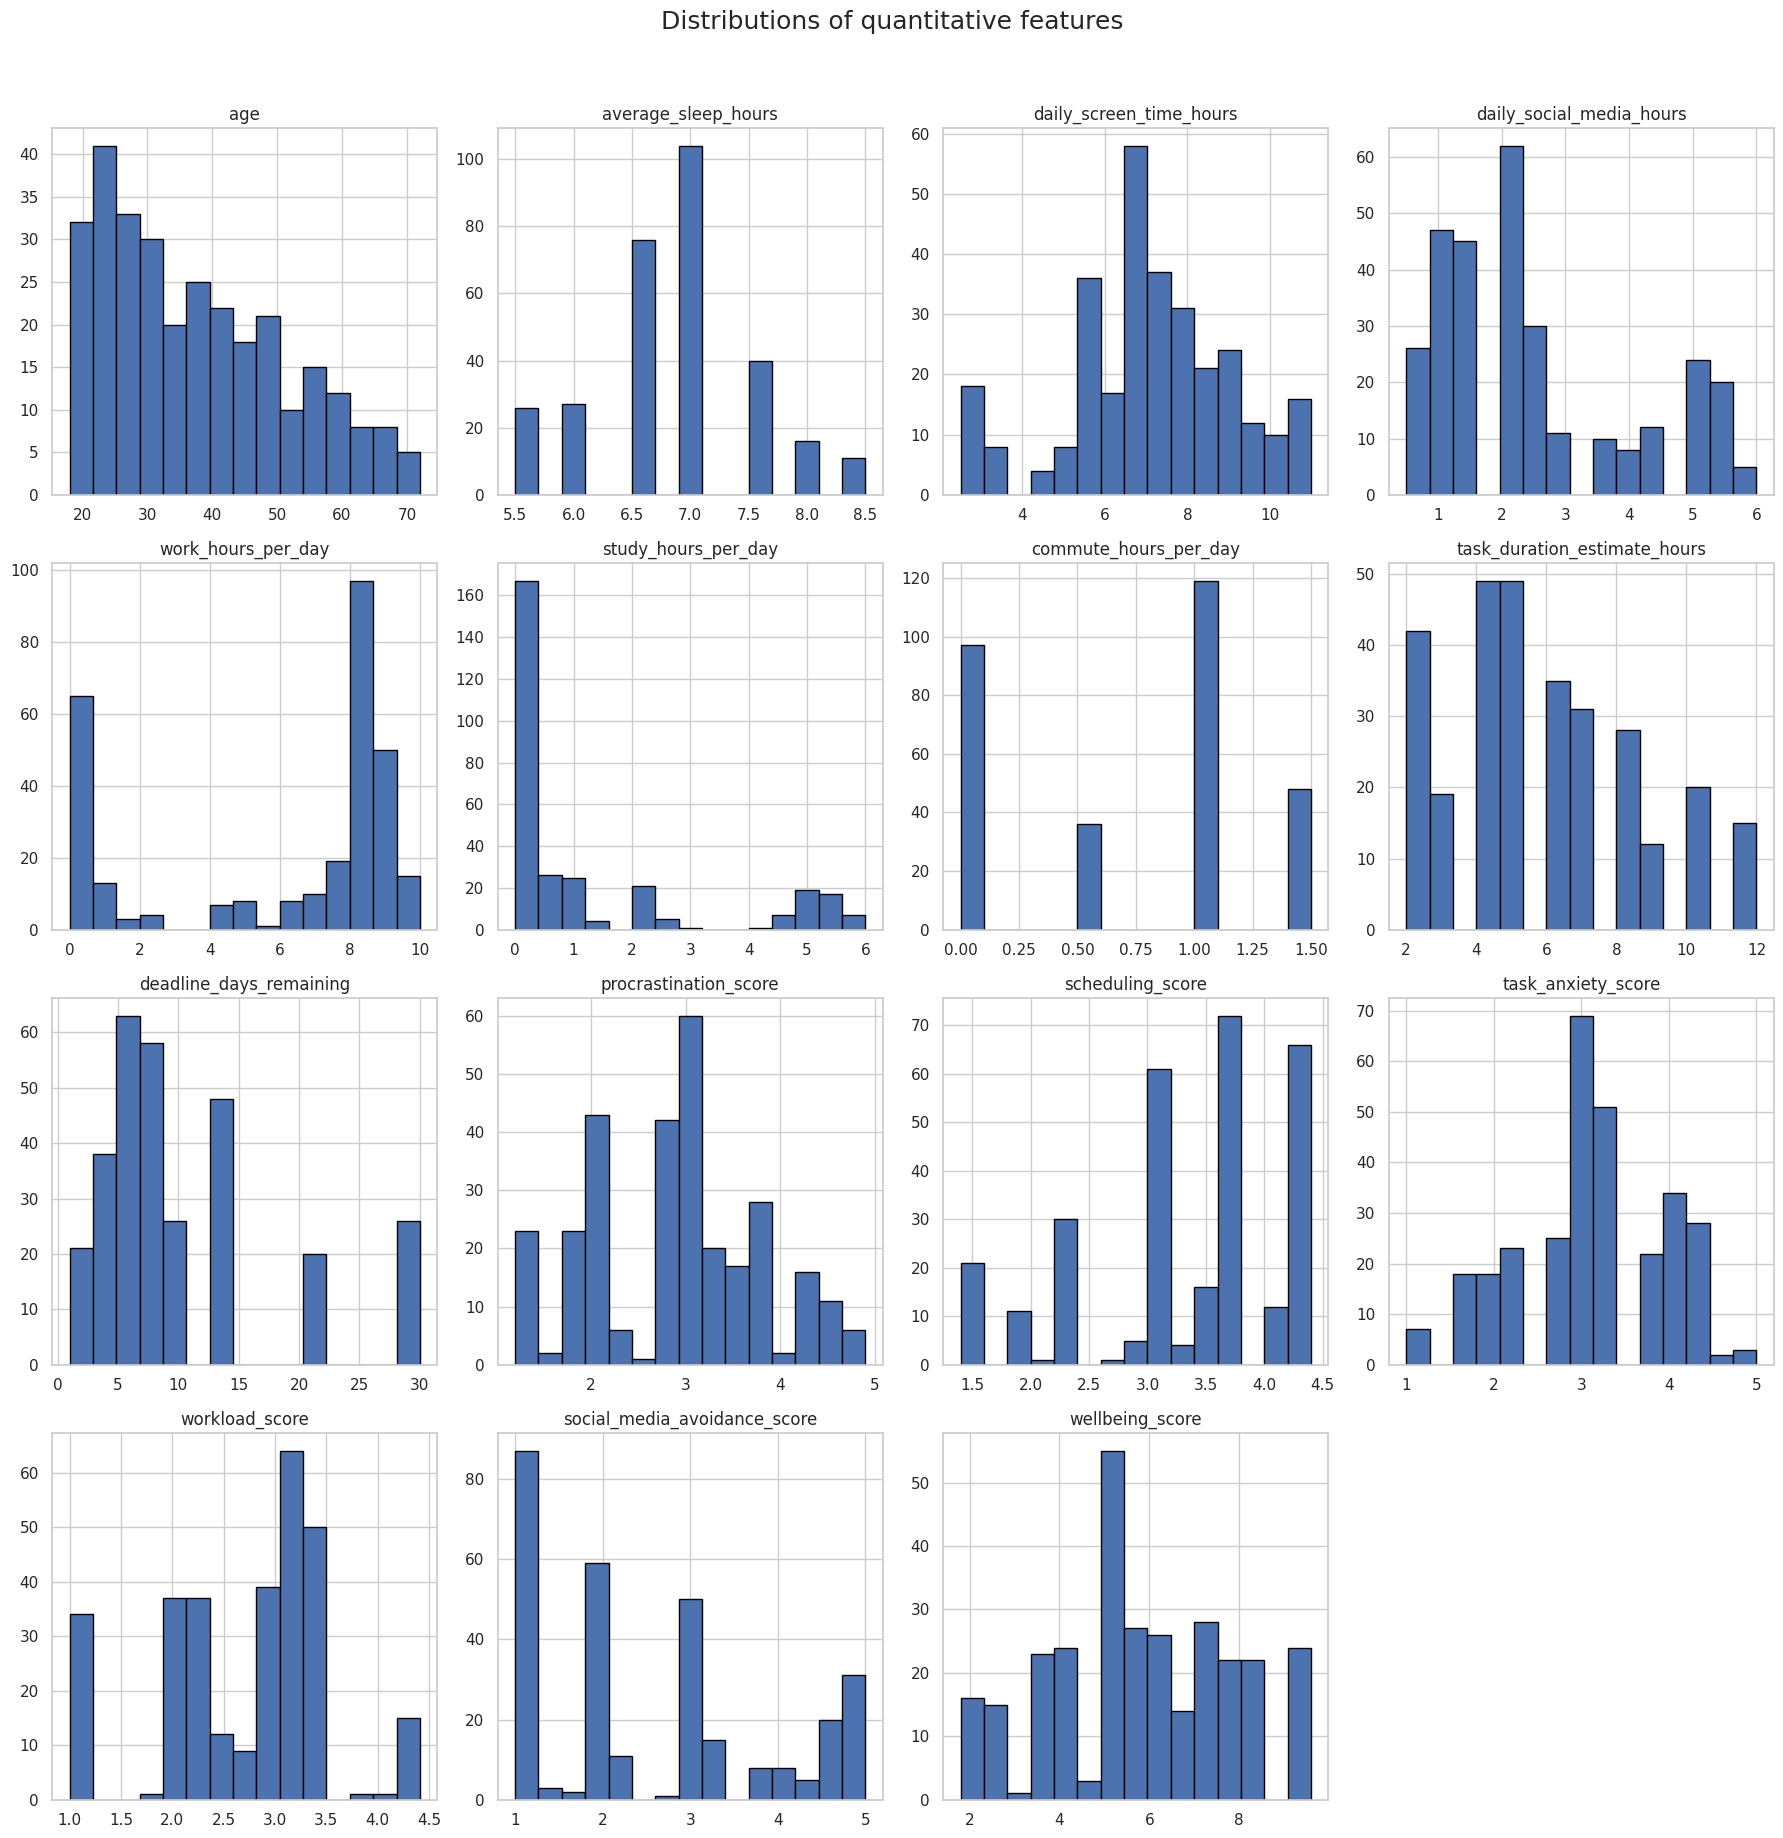

In [23]:
df[quantitative_cols].hist(
    bins=15,
    figsize=(18, 18),
    edgecolor="black"
)

plt.suptitle(
    "Distributions of quantitative features",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

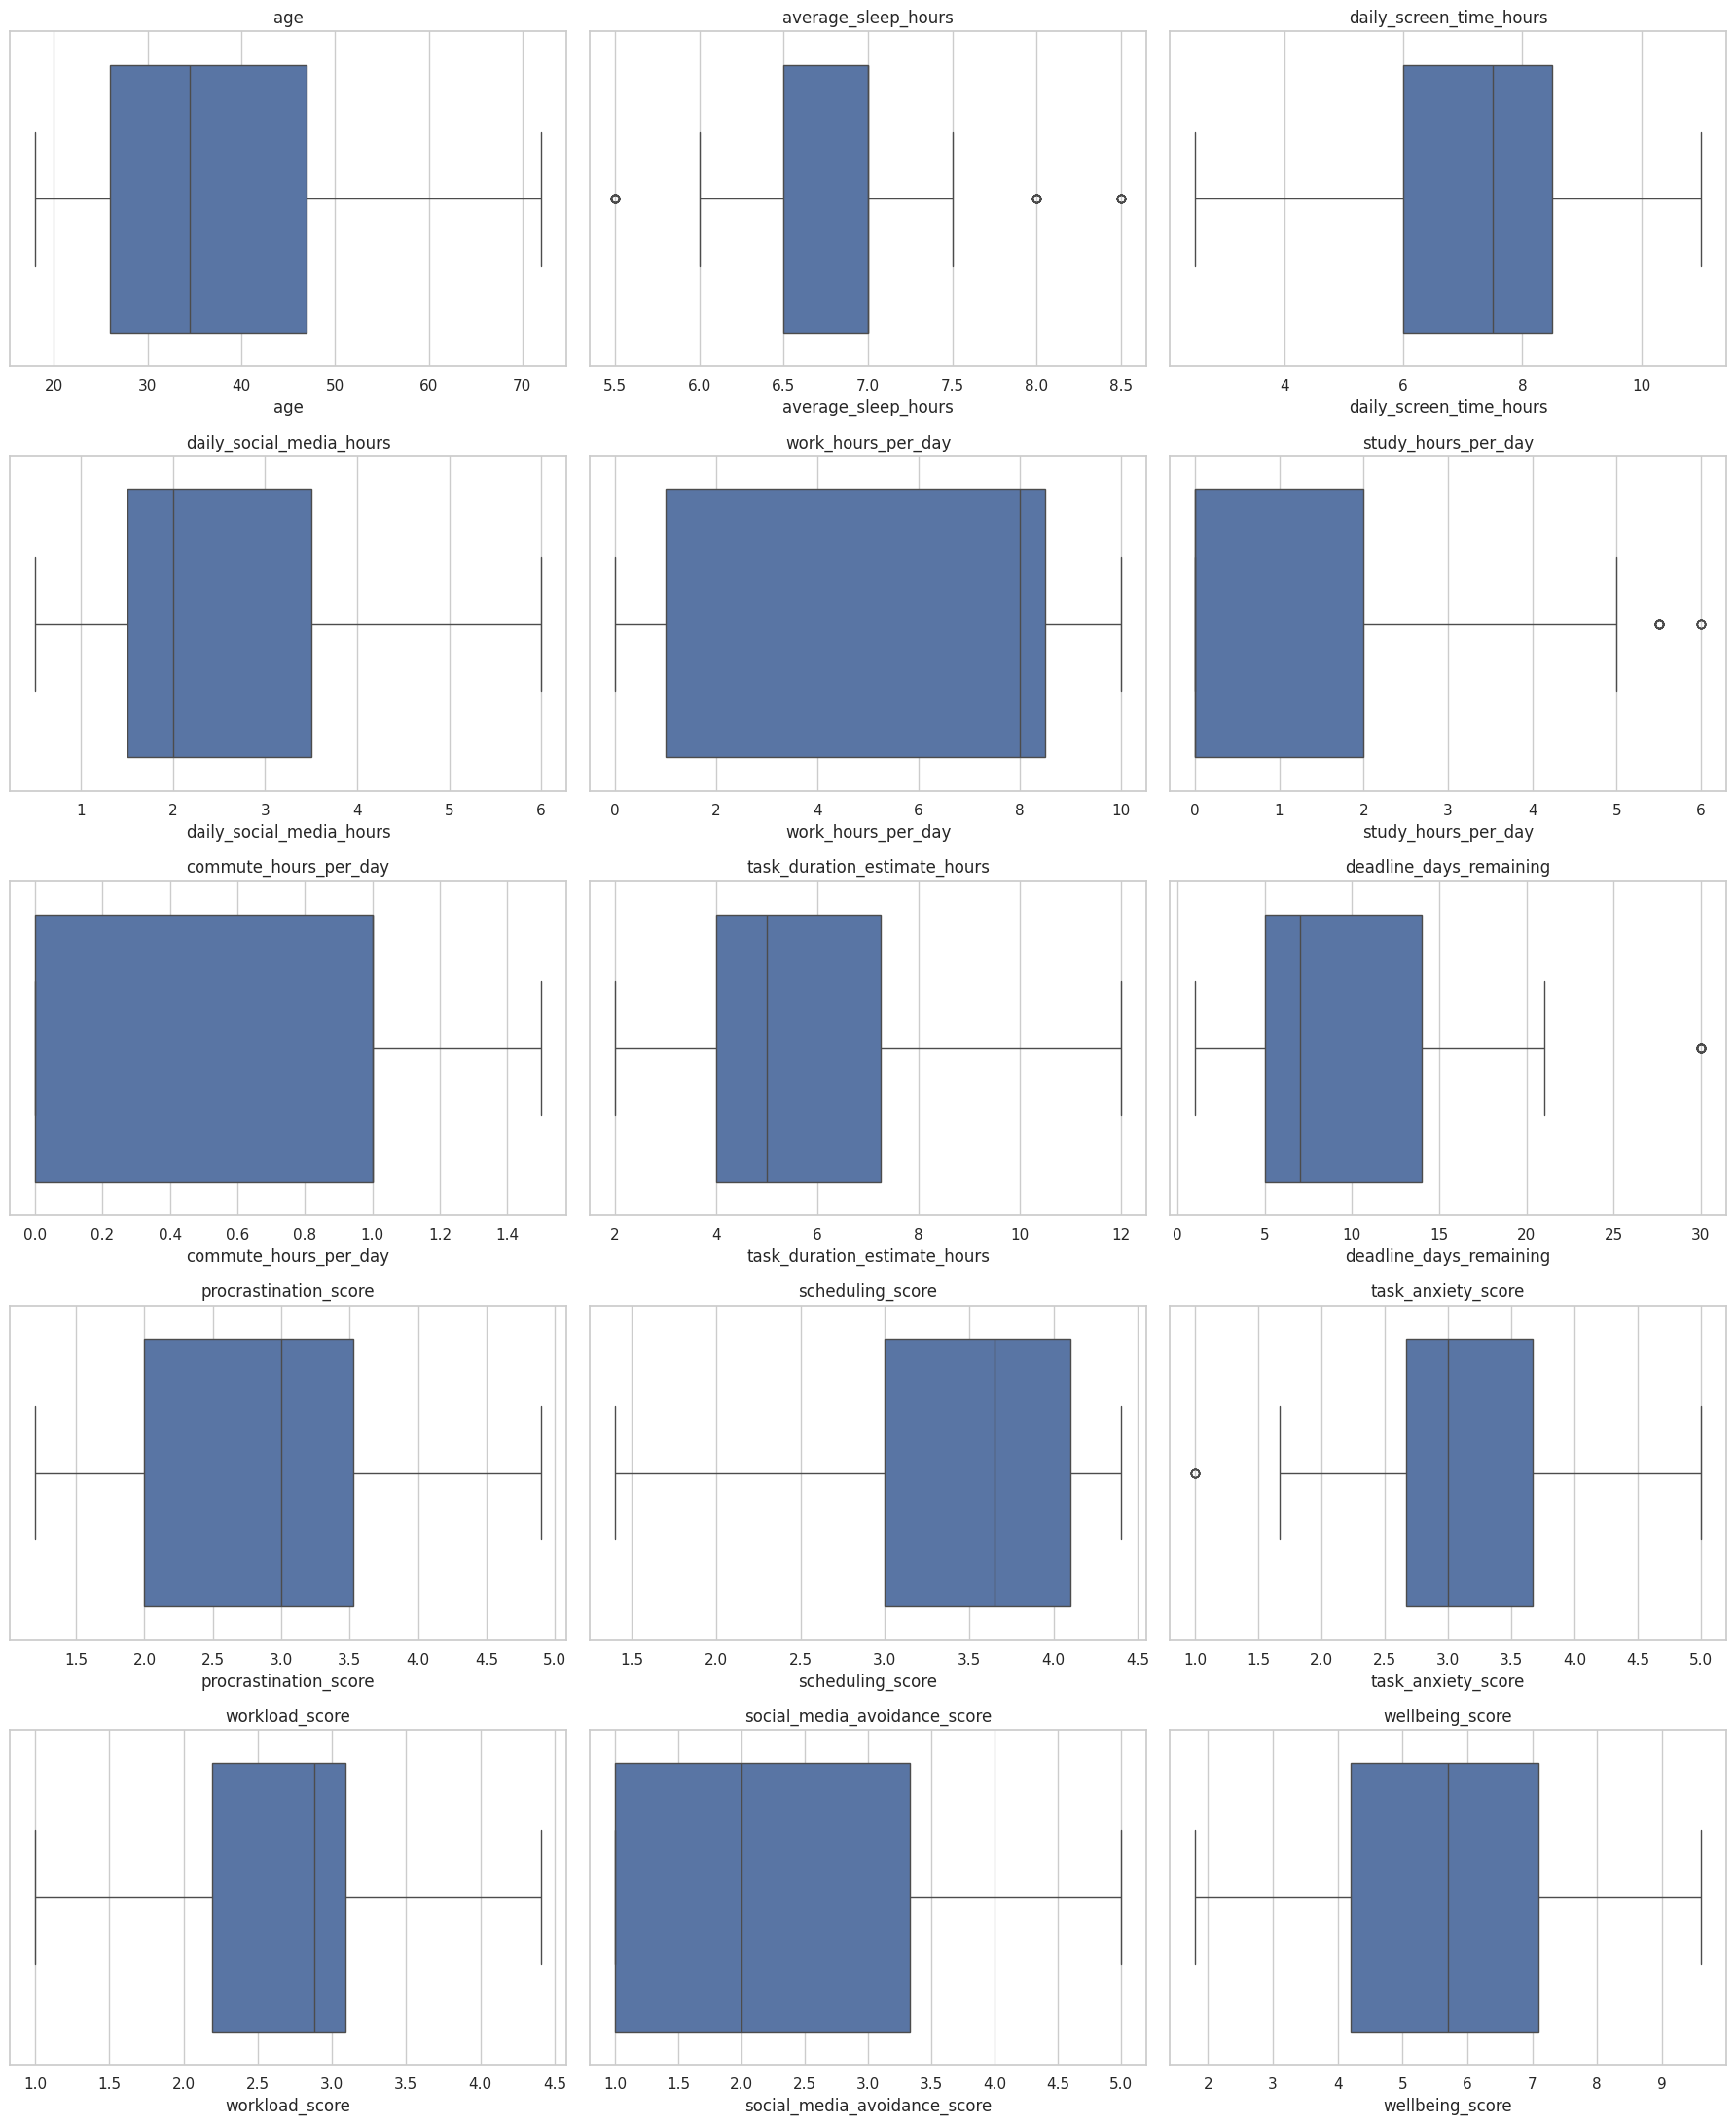

In [25]:
fig, axes = plt.subplots(
    5,
    3,
    figsize=(18, 22)
)

axes = axes.flatten()

for ax, col in zip(axes, quantitative_cols):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [28]:
categorical_ordinal = [
    "age_group",
    "education_level",
    "sleep_quality",
    "physical_activity_frequency",
    "perceived_workload",
    "planning_style",
    "social_media_check_frequency",
    "social_media_during_work_or_study"
]

categorical_nominal = [
    "gender",
    "employment_status",
    "occupation_category",
    "task_type",
    "scheduling_method",
    "primary_social_platform",
    "notifications_enabled",
    "primary_procrastination_trigger"
]

categorical_cols = (
    categorical_ordinal
    + categorical_nominal
)

In [29]:
frequency_tables = []

for col in categorical_cols:

    counts = df[col].value_counts(dropna=False)

    percentages = (
        df[col]
        .value_counts(dropna=False, normalize=True)
        * 100
    )

    temp = pd.DataFrame({
        "feature": col,
        "category": counts.index.astype(str),
        "count": counts.values,
        "percent": percentages.values
    })

    frequency_tables.append(temp)

category_frequencies = pd.concat(
    frequency_tables,
    ignore_index=True
)

display(category_frequencies.round(2))

,feature,category,count,percent
0,age_group,30-39,65,21.67
1,age_group,40-49,57,19.00
2,age_group,25-29,52,17.33
3,age_group,21-24,41,13.67
4,age_group,50-59,35,11.67
...,...,...,...,...
96,primary_procrastination_trigger,Entertainment,21,7.00
97,primary_procrastination_trigger,Fear of failure,21,7.00
98,primary_procrastination_trigger,Perfectionism,18,6.00
99,primary_procrastination_trigger,Lack of clarity,7,2.33


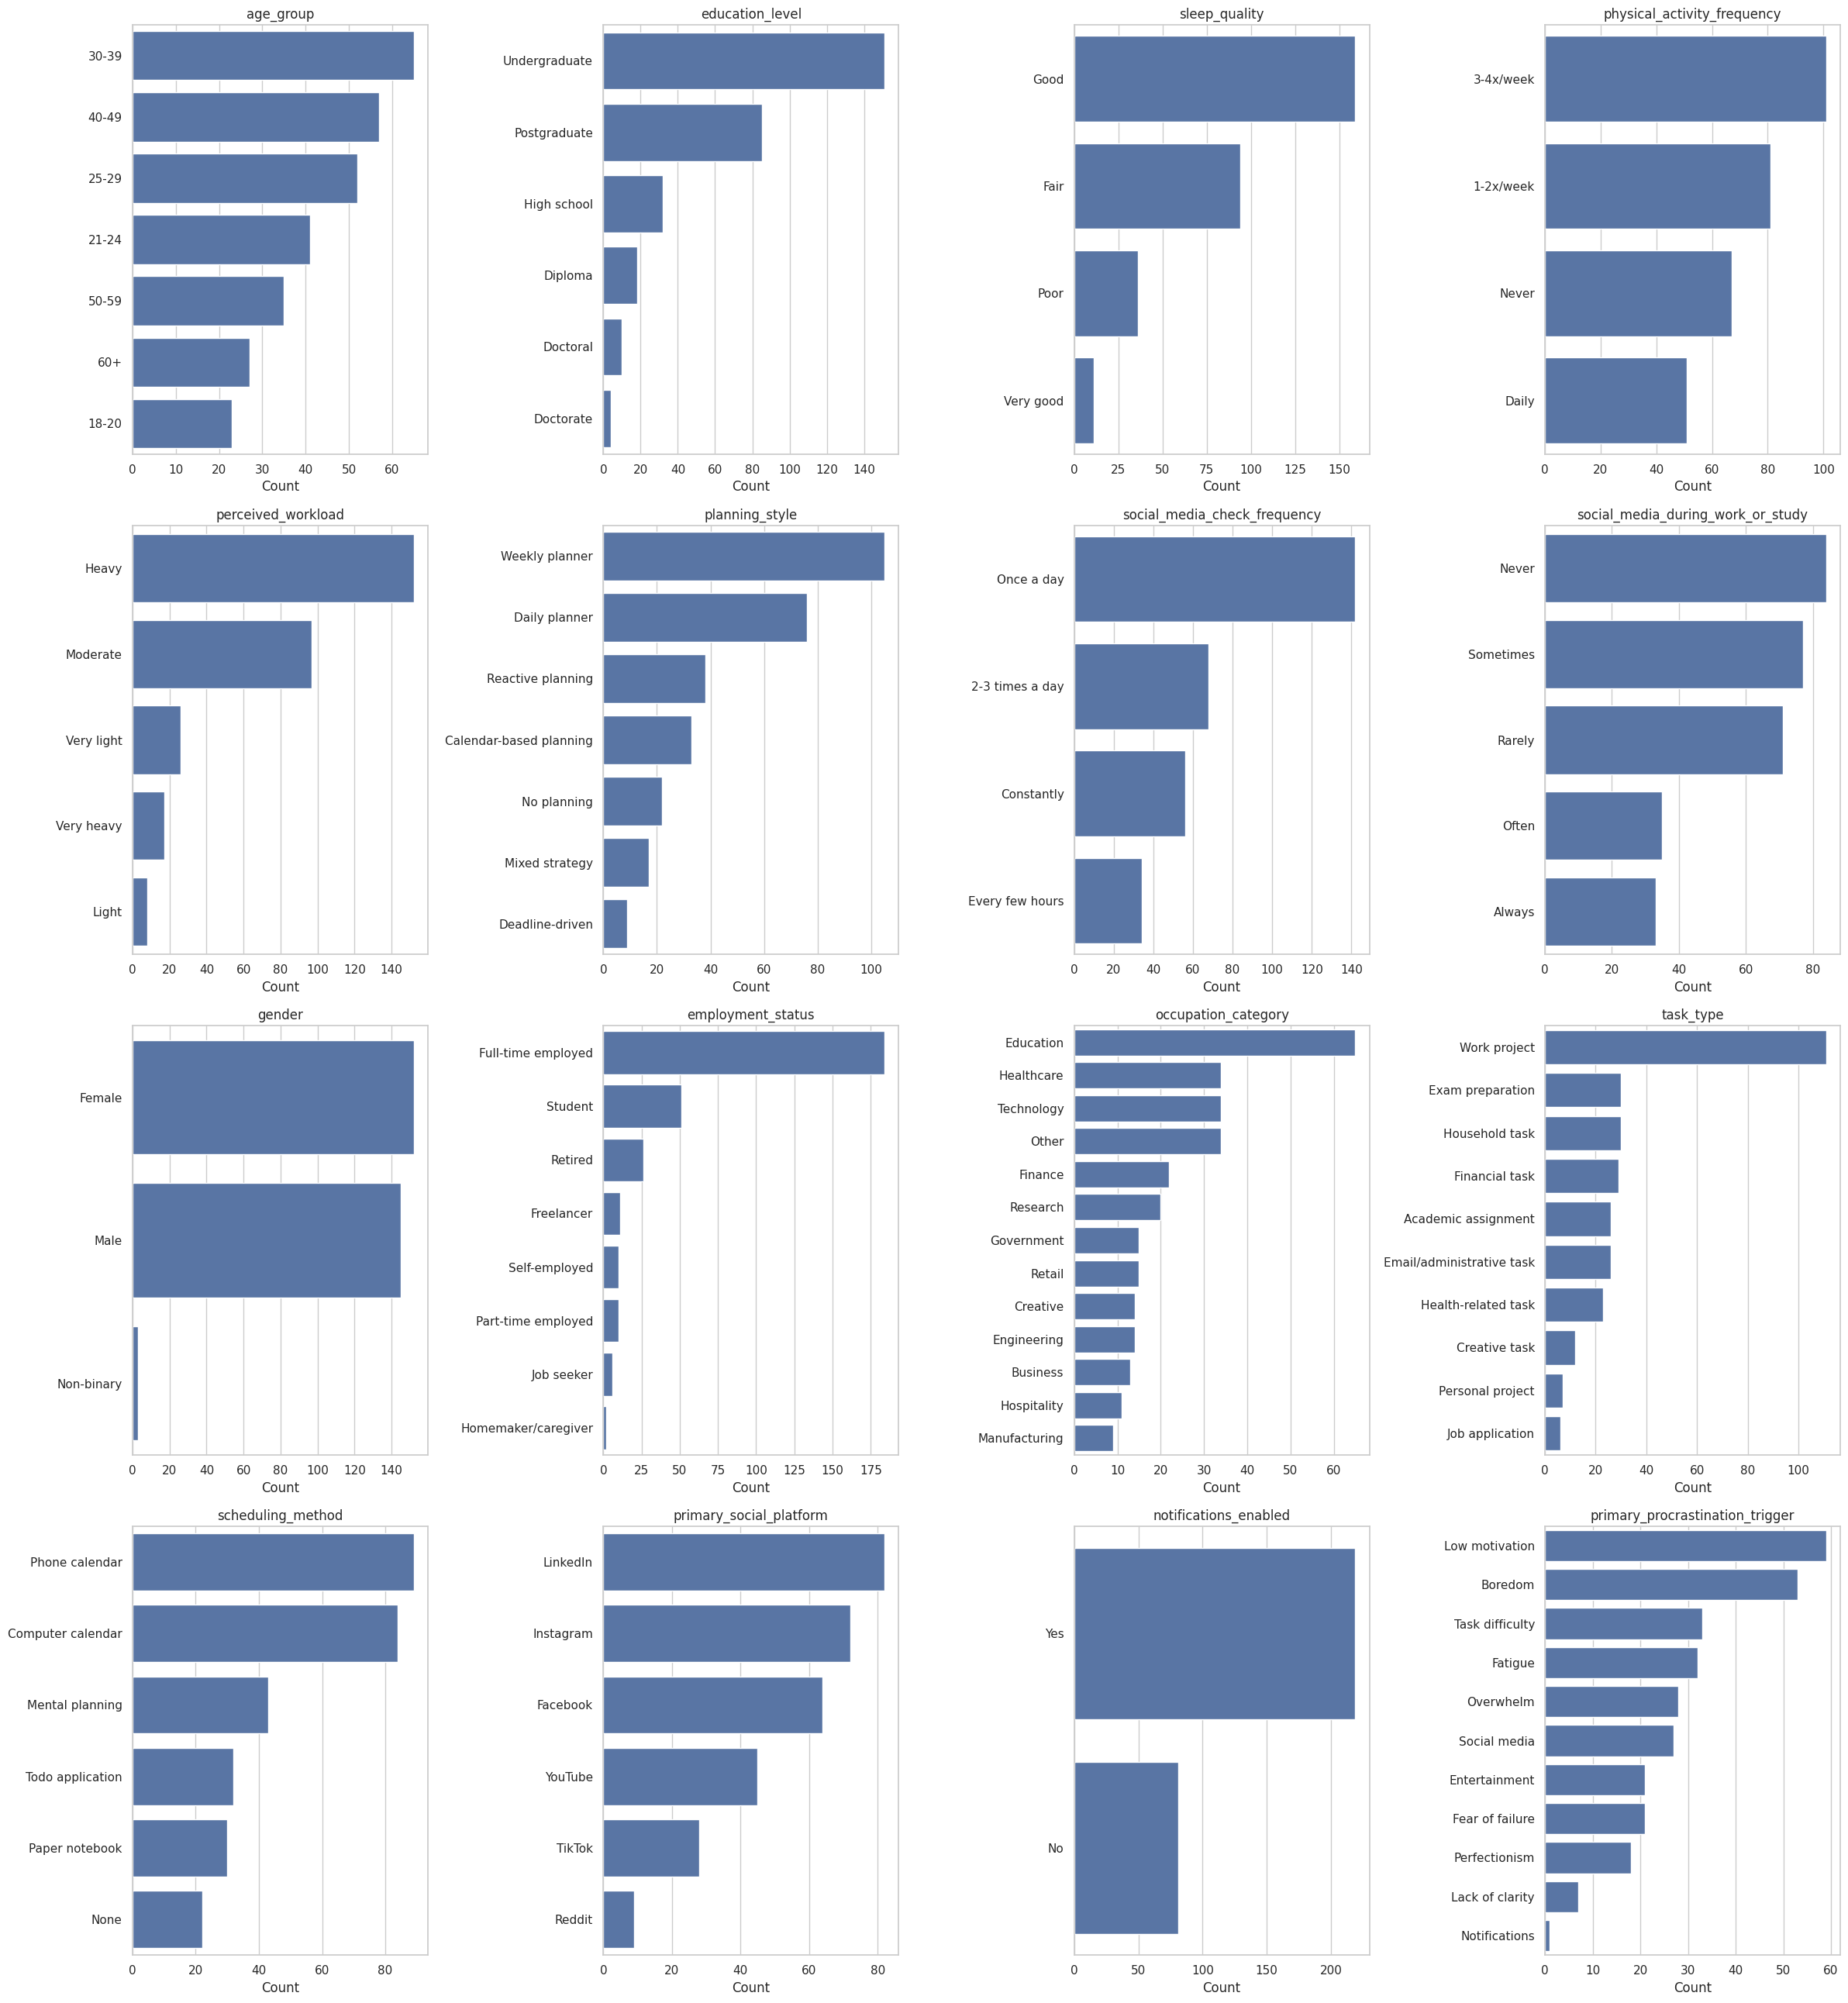

In [31]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(24, 26)
)

axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [32]:
rare_categories = []

threshold = 0.05

for col in categorical_cols:

    freq = df[col].value_counts(normalize=True)

    rare = freq[freq < threshold]

    for category, proportion in rare.items():

        rare_categories.append({
            "feature": col,
            "category": category,
            "count": int((df[col] == category).sum()),
            "percent": proportion * 100
        })

rare_table = pd.DataFrame(rare_categories)

display(
    rare_table
    .sort_values(["feature", "percent"])
    .round(2)
)

,feature,category,count,percent
1,education_level,Doctorate,4,1.33
0,education_level,Doctoral,10,3.33
10,employment_status,Homemaker/caregiver,2,0.67
9,employment_status,Job seeker,6,2.00
7,employment_status,Self-employed,10,3.33
8,employment_status,Part-time employed,10,3.33
6,employment_status,Freelancer,11,3.67
5,gender,Non-binary,3,1.00
15,occupation_category,Manufacturing,9,3.00
14,occupation_category,Hospitality,11,3.67


In [33]:
corr_cols = [
    col
    for col in df.select_dtypes(include=np.number).columns
    if df[col].nunique(dropna=True) > 1
    and col != "unlabeled_extra_field"
]

corr_matrix = df[corr_cols].corr()

print("Размер корреляционной матрицы:")
print(corr_matrix.shape)

display(corr_matrix.round(2))

Размер корреляционной матрицы:
(49, 49)


,age,average_sleep_hours,daily_screen_time_hours,daily_social_media_hours,work_hours_per_day,study_hours_per_day,commute_hours_per_day,task_importance,task_difficulty,task_interest,task_anxiety,task_clarity,task_complexity,task_duration_estimate_hours,deadline_days_remaining,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,social_media_as_task_avoidance,stress_rating,mood_rating,energy_rating,concentration_difficulty,feeling_overwhelmed_frequency,work_life_balance,perceived_control,procrastination_score,scheduling_score,task_anxiety_score,workload_score,social_media_avoidance_score,wellbeing_score
age,1.00,0.84,-0.83,-0.82,0.12,-0.59,0.13,-0.42,-0.35,0.40,-0.72,0.82,-0.33,-0.20,0.61,-0.79,-0.78,-0.71,-0.80,-0.62,-0.73,-0.74,-0.80,-0.67,-0.73,0.82,0.71,0.68,0.82,0.81,0.70,0.82,0.77,-0.80,-0.06,-0.79,-0.79,0.80,0.81,-0.76,-0.78,0.82,0.83,-0.79,0.81,-0.56,-0.12,-0.80,0.82
average_sleep_hours,0.84,1.00,-0.89,-0.85,0.12,-0.64,0.12,-0.41,-0.41,0.35,-0.75,0.79,-0.38,-0.26,0.62,-0.86,-0.84,-0.84,-0.87,-0.72,-0.77,-0.77,-0.86,-0.70,-0.78,0.85,0.75,0.75,0.85,0.85,0.76,0.85,0.83,-0.85,0.10,-0.85,-0.87,0.88,0.88,-0.85,-0.87,0.90,0.89,-0.86,0.85,-0.63,-0.13,-0.86,0.90
daily_screen_time_hours,-0.83,-0.89,1.00,0.88,-0.11,0.68,-0.21,0.58,0.59,-0.30,0.86,-0.80,0.57,0.44,-0.67,0.89,0.87,0.87,0.89,0.77,0.82,0.83,0.88,0.68,0.83,-0.81,-0.69,-0.69,-0.81,-0.81,-0.69,-0.81,-0.77,0.87,-0.15,0.83,0.89,-0.87,-0.88,0.89,0.88,-0.89,-0.89,0.89,-0.81,0.76,0.19,0.85,-0.90
daily_social_media_hours,-0.82,-0.85,0.88,1.00,-0.51,0.84,-0.45,0.30,0.27,-0.33,0.74,-0.80,0.23,0.08,-0.47,0.84,0.80,0.81,0.84,0.77,0.80,0.70,0.83,0.69,0.69,-0.91,-0.87,-0.89,-0.92,-0.92,-0.88,-0.91,-0.88,0.88,-0.24,0.93,0.80,-0.88,-0.84,0.85,0.81,-0.81,-0.88,0.83,-0.93,0.52,-0.23,0.93,-0.86
work_hours_per_day,0.12,0.12,-0.11,-0.51,1.00,-0.64,0.77,0.30,0.34,0.10,-0.11,0.20,0.39,0.46,-0.25,-0.23,-0.15,-0.19,-0.21,-0.31,-0.28,0.00,-0.20,-0.19,-0.01,0.44,0.60,0.62,0.45,0.46,0.60,0.45,0.41,-0.31,0.41,-0.47,-0.10,0.30,0.21,-0.25,-0.17,0.10,0.26,-0.19,0.48,0.16,0.87,-0.45,0.21
study_hours_per_day,-0.59,-0.64,0.68,0.84,-0.64,1.00,-0.61,0.36,0.25,-0.30,0.70,-0.64,0.21,0.07,-0.42,0.79,0.74,0.68,0.78,0.63,0.79,0.63,0.77,0.51,0.62,-0.75,-0.76,-0.80,-0.75,-0.75,-0.78,-0.75,-0.73,0.76,-0.53,0.82,0.72,-0.82,-0.76,0.80,0.76,-0.72,-0.78,0.75,-0.79,0.49,-0.24,0.81,-0.76
commute_hours_per_day,0.13,0.12,-0.21,-0.45,0.77,-0.61,1.00,0.15,0.08,-0.22,-0.13,0.22,0.11,0.12,-0.28,-0.23,-0.17,-0.25,-0.21,-0.33,-0.34,-0.06,-0.18,-0.27,-0.07,0.33,0.42,0.45,0.35,0.35,0.41,0.34,0.27,-0.24,0.31,-0.41,-0.12,0.28,0.21,-0.27,-0.19,0.14,0.25,-0.22,0.36,-0.02,0.62,-0.40,0.21
task_importance,-0.42,-0.41,0.58,0.30,0.30,0.36,0.15,1.00,0.80,-0.19,0.73,-0.31,0.79,0.65,-0.69,0.58,0.61,0.43,0.58,0.21,0.49,0.67,0.59,0.13,0.64,-0.25,-0.09,-0.14,-0.26,-0.26,-0.15,-0.26,-0.28,0.43,-0.37,0.29,0.62,-0.45,-0.50,0.53,0.59,-0.54,-0.47,0.55,-0.27,0.84,0.59,0.32,-0.49
task_difficulty,-0.35,-0.41,0.59,0.27,0.34,0.25,0.08,0.80,1.00,0.00,0.73,-0.32,0.97,0.90,-0.57,0.55,0.60,0.54,0.56,0.45,0.54,0.68,0.57,0.30,0.67,-0.24,-0.10,-0.11,-0.26,-0.26,-0.10,-0.26,-0.21,0.47,-0.16,0.32,0.61,-0.45,-0.49,0.56,0.59,-0.54,-0.47,0.59,-0.25,0.90,0.59,0.35,-0.52
task_interest,0.40,0.35,-0.30,-0.33,0.10,-0.30,-0.22,-0.19,0.00,1.00,-0.40,0.42,0.00,0.16,0.63,-0.43,-0.43,-0.31,-0.43,-0.34,-0.34,-0.41,-0.44,-0.21,-0.39,0.47,0.45,0.42,0.45,0.45,0.46,0.46,0.47,-0.48,0.07,-0.35,-0.43,0.44,0.44,-0.38,-0.42,0.43,0.45,-0.40,0.48,-0.10,-0.06,-0.36,0.44


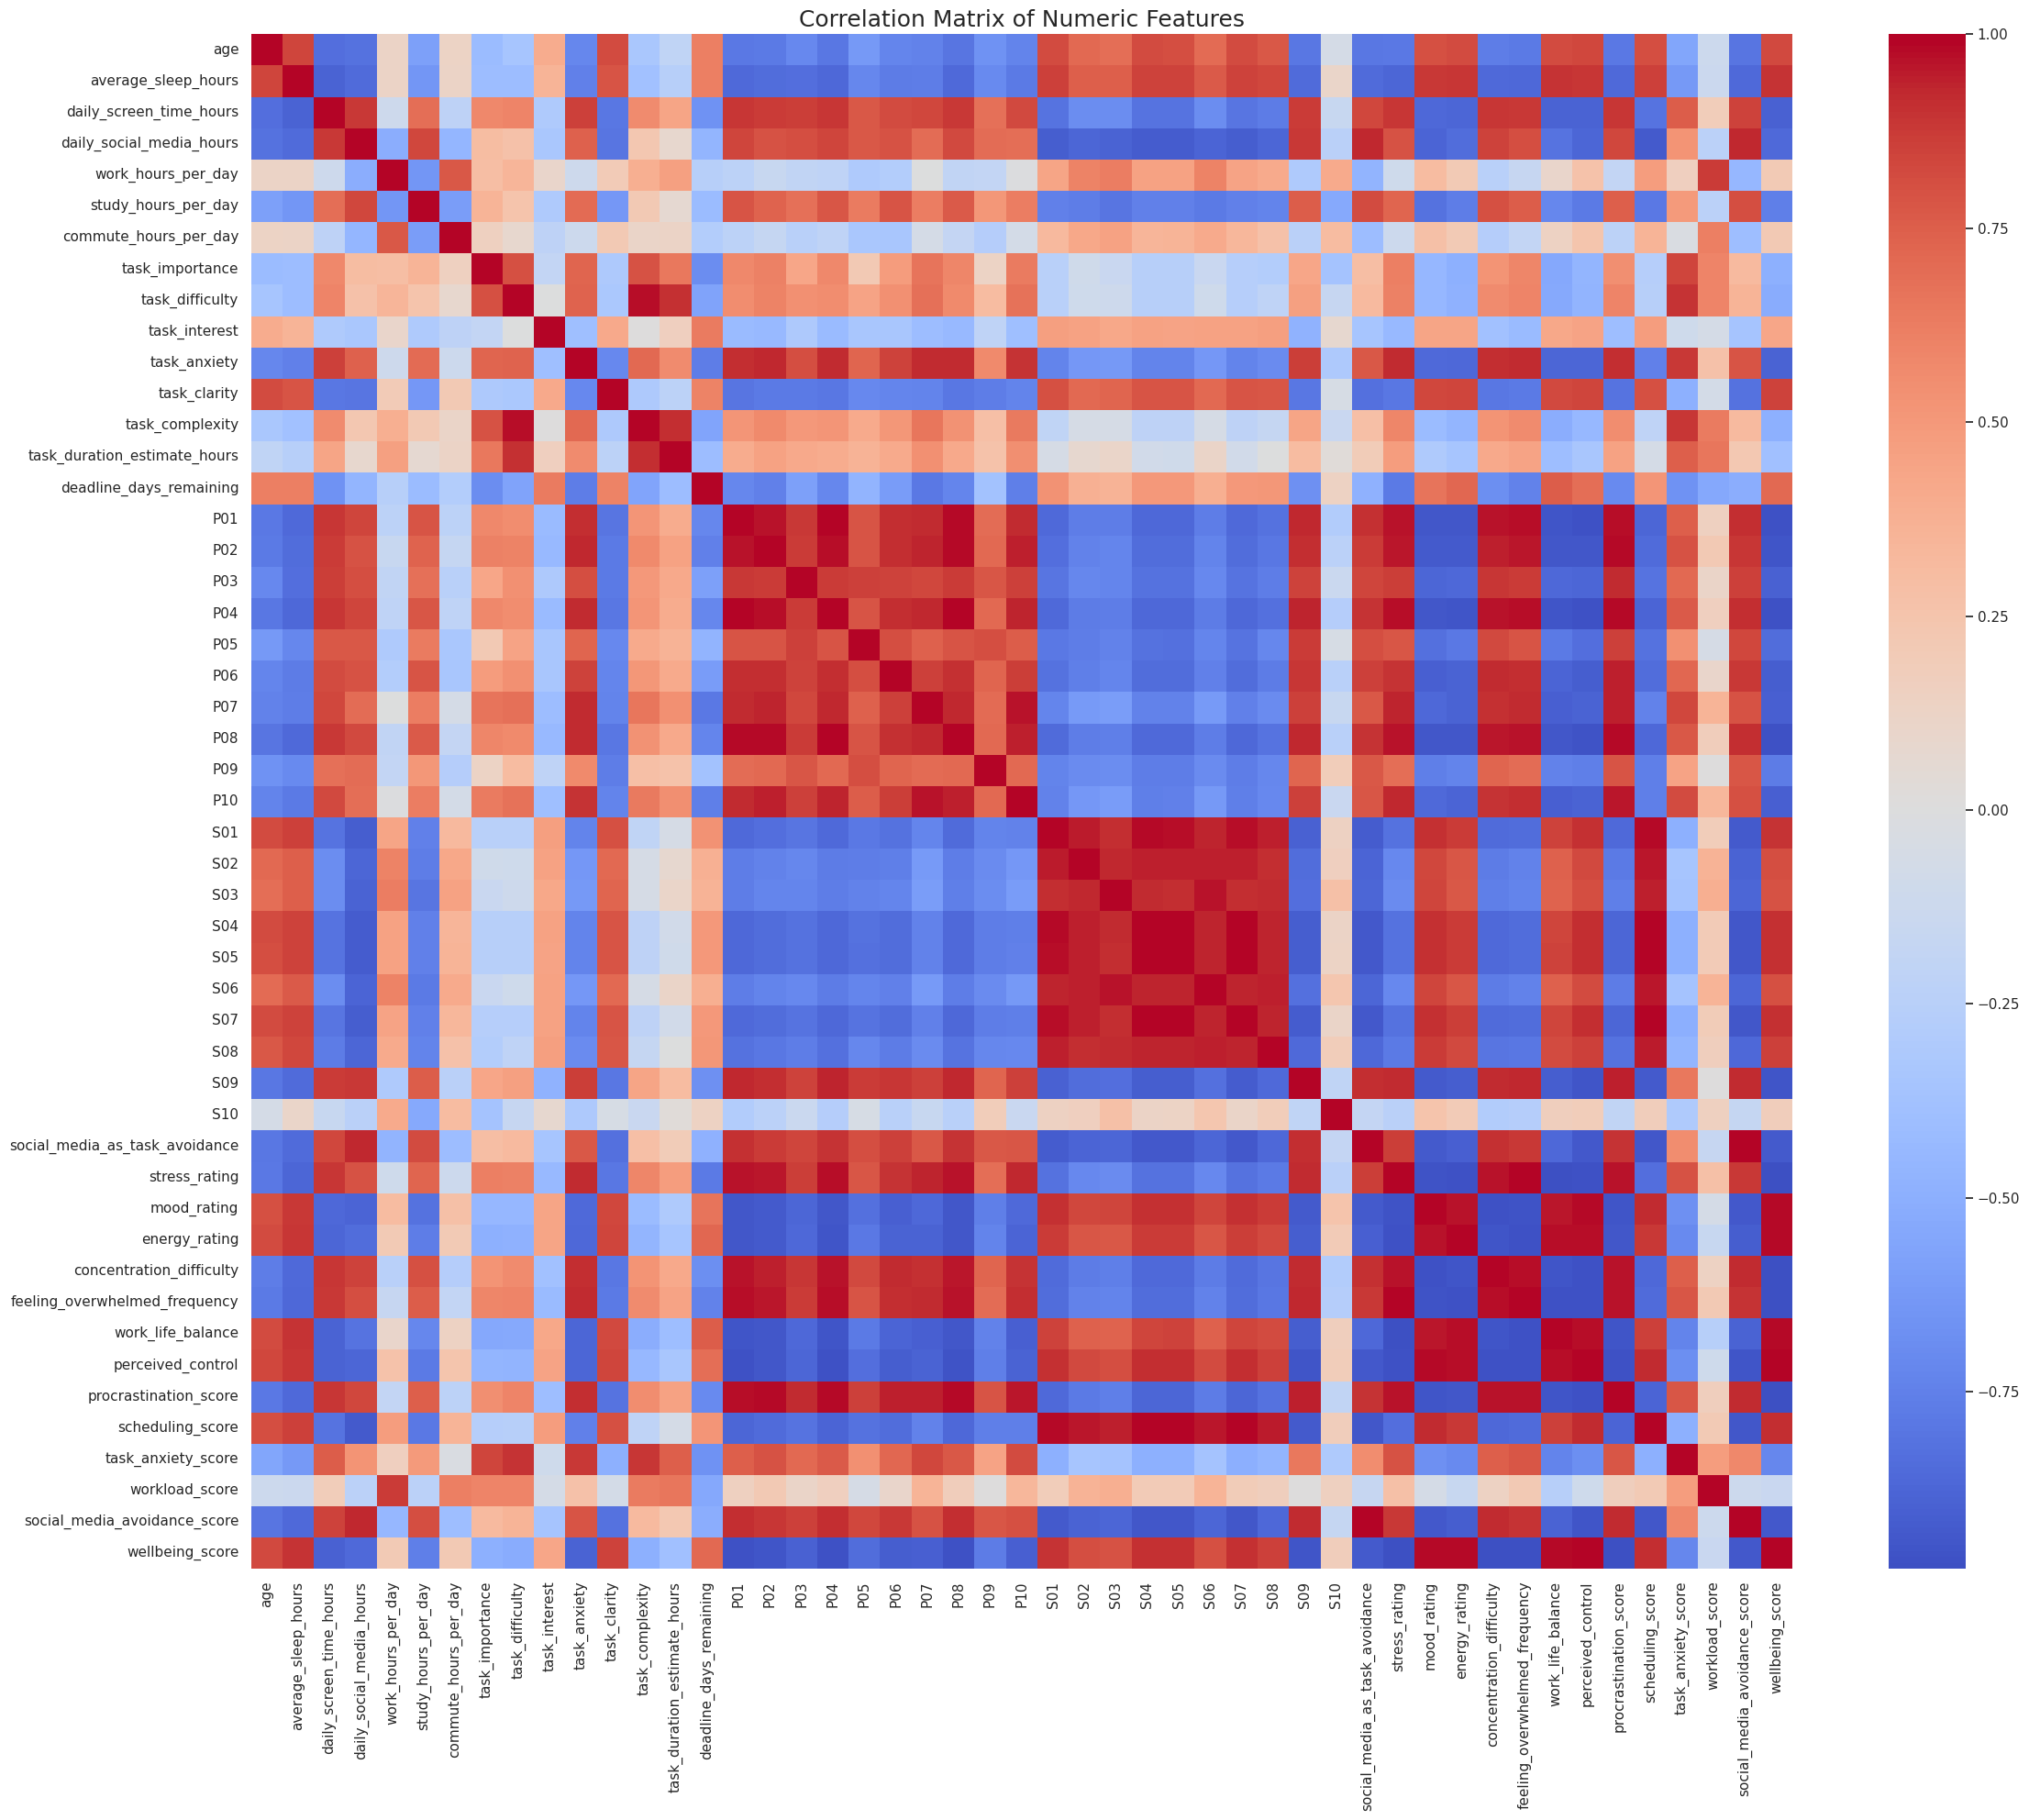

In [34]:
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title(
    "Correlation Matrix of Numeric Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [35]:
upper_triangle = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

correlation_pairs["abs_correlation"] = (
    correlation_pairs["correlation"].abs()
)

top_correlations = (
    correlation_pairs
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .head(20)
)

display(top_correlations.round(3))

,feature_1,feature_2,correlation,abs_correlation
968,S04,S07,0.996,0.996
966,S04,S05,0.996,0.996
1096,social_media_as_task_avoidance,social_media_avoidance_score,0.994,0.994
1160,perceived_control,wellbeing_score,0.992,0.992
981,S04,scheduling_score,0.991,0.991
987,S05,S07,0.991,0.991
1000,S05,scheduling_score,0.991,0.991
1035,S07,scheduling_score,0.990,0.990
617,P01,P04,0.989,0.989
714,P04,P08,0.988,0.988


In [37]:
target = "procrastination_score"

target_correlations = (
    corr_matrix[target]
    .drop(target)
)

target_correlations = target_correlations[
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .index
]

display(
    target_correlations
    .head(15)
    .to_frame("correlation_with_procrastination")
    .round(3)
)

,correlation_with_procrastination
P04,0.982
P08,0.980
P02,0.977
wellbeing_score,-0.975
P01,0.973
feeling_overwhelmed_frequency,0.966
concentration_difficulty,0.965
perceived_control,-0.964
stress_rating,0.963
P10,0.955


In [38]:
top_5_features = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

pairplot_cols = [
    target
] + top_5_features

print("Признаки для pairplot:")
print(pairplot_cols)

Признаки для pairplot:
['procrastination_score', 'P04', 'P08', 'P02', 'wellbeing_score', 'P01']


In [39]:
print(
    "Тип target:",
    df["procrastination_score"].dtype
)

print(
    "Количество уникальных значений:",
    df["procrastination_score"].nunique()
)

print(
    df["procrastination_score"]
    .describe()
    .round(3)
)

Тип target: float64
Количество уникальных значений: 31
count    300.000
mean       2.892
std        0.887
min        1.200
25%        2.000
50%        3.000
75%        3.525
max        4.900
Name: procrastination_score, dtype: float64


In [40]:
print(
    "Тип target:",
    df["procrastination_score"].dtype
)

print(
    "Количество уникальных значений:",
    df["procrastination_score"].nunique()
)

print(
    df["procrastination_score"]
    .describe()
    .round(3)
)

Тип target: float64
Количество уникальных значений: 31
count    300.000
mean       2.892
std        0.887
min        1.200
25%        2.000
50%        3.000
75%        3.525
max        4.900
Name: procrastination_score, dtype: float64


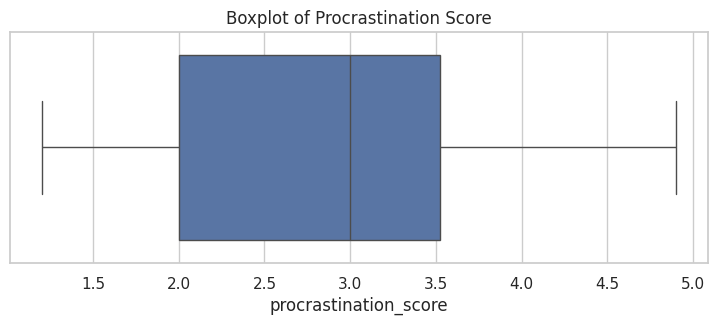

In [41]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    x=df["procrastination_score"]
)

plt.title(
    "Boxplot of Procrastination Score"
)

plt.show()

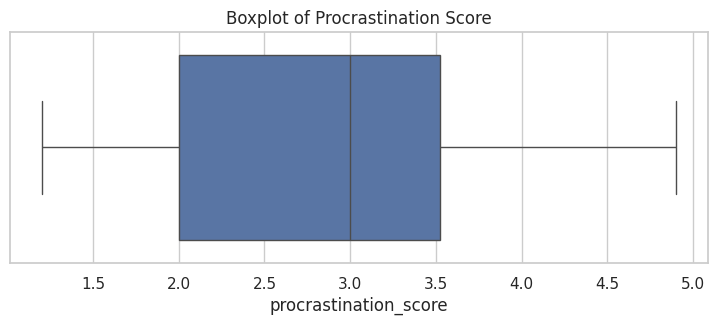

In [42]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    x=df["procrastination_score"]
)

plt.title(
    "Boxplot of Procrastination Score"
)

plt.show()

In [43]:
print(
    "education_level:",
    df["education_level"].unique()
)

print(
    "\ndata_source:",
    df["data_source"].unique()
)

print(
    "\nsynthetic_flag:",
    df["synthetic_flag"].unique()
)

education_level: ['Undergraduate' 'Postgraduate' 'High school' 'Doctoral' 'Diploma'
 'Doctorate']

data_source: ['synthetic_ai']

synthetic_flag: [1]


In [44]:
print("=== FINAL CHECK ===")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())

print(
    "Missing values:",
    int(df.isna().sum().sum())
)

print(
    "Unknown extra field missing:",
    int(df["unlabeled_extra_field"].isna().sum())
)

print(
    "Target mean:",
    round(df["procrastination_score"].mean(), 2)
)

print(
    "Target median:",
    round(df["procrastination_score"].median(), 2)
)

=== FINAL CHECK ===
Rows: 300
Columns: 69
Duplicates: 0
Missing values: 65
Unknown extra field missing: 65
Target mean: 2.89
Target median: 3.0


## Вывод по результатам EDA

1. **Обнаружена проблема структуры исходного CSV-файла.** Заголовок датасета содержит 68 полей, однако из 300 наблюдений 235 строк содержат 69 значений, а 65 строк — 68. Дополнительное неименованное значение было сохранено как технический признак `unlabeled_extra_field`, чтобы не терять данные. Для 65 наблюдений этот признак отсутствует. На следующем этапе необходимо уточнить исходную схему данных или исключить данный признак, если определить его смысл невозможно.

2. **В основных именованных признаках пропуски и полные дубликаты не обнаружены.** Полных дубликатов — 0. При этом `data_source` и `synthetic_flag` являются константными признаками: все наблюдения имеют `data_source = synthetic_ai` и `synthetic_flag = 1`. Такие признаки не несут информации для будущей модели и могут быть исключены при подготовке данных.

3. **В категориальных данных обнаружены редкие и потенциально несогласованные категории.** Например, в `education_level` одновременно присутствуют `Doctoral` и `Doctorate`, которые, вероятно, обозначают одну категорию. Также имеются очень редкие значения: `Non-binary` — 3 наблюдения, `Homemaker/caregiver` — 2, `Notifications` как причина прокрастинации — 1 и другие. На следующем занятии необходимо нормализовать текстовые категории и определить, следует ли объединять некоторые редкие значения в более общие группы.

4. **Метод IQR обнаружил потенциальные выбросы в ряде числовых признаков.** Наибольшее количество отмечено для `average_sleep_hours` — 53, `deadline_days_remaining` — 26, `study_hours_per_day` — 24 и `task_anxiety_score` — 7. Однако эти значения остаются реалистичными с точки зрения предметной области, поэтому автоматически удалять их нельзя. На этапе очистки следует дополнительно проверить диапазоны и только после этого решать вопрос об удалении, ограничении или использовании устойчивых к выбросам методов.

5. **Корреляционный анализ выявил большое количество очень сильных связей между признаками.** Например, корреляция `S04` и `S07` составляет приблизительно 0.996, `social_media_as_task_avoidance` и `social_media_avoidance_score` — около 0.994, а `perceived_control` и `wellbeing_score` — около 0.992. Это указывает на возможную избыточность признаков и мультиколлинеарность. Перед построением модели необходимо определить, какие исходные вопросы и агрегированные показатели следует оставить.

6. **Целевая переменная `procrastination_score` является числовой непрерывной переменной, а не классом.** Она содержит 31 уникальное значение, среднее составляет приблизительно 2.89, медиана — 3.00, а выраженной асимметрии распределения не наблюдается. Следовательно, проверка дисбаланса классов для текущей постановки задачи неприменима. Если в дальнейшем будет решено преобразовать показатель прокрастинации в категории, границы классов должны быть обоснованы отдельно.

7. **Обнаружен риск утечки информации и сильной избыточности при будущем моделировании.** `procrastination_score` очень сильно коррелирует с отдельными вопросами шкалы: `P04` — около 0.982, `P08` — около 0.980, `P02` — около 0.977 и `P01` — около 0.973. Это может означать, что итоговый показатель рассчитан непосредственно на основе этих вопросов. На следующем занятии перед подготовкой модели необходимо разделить исходные признаки и производные агрегированные показатели, устранить потенциальную утечку целевой переменной, нормализовать категории и определить стратегию обработки выбросов и редких значений.
